# Classify Handwritten Digits with Tensorflow

Classifying handwritten digits is a fundamental problem in machine learning and computer vision. In this project, handwritten digit classification is implemented using TensorFlow 2.x with the Keras API on the MNIST dataset.

A neural network–based classifier is used to learn patterns from pixel values of handwritten digit images. The model processes each image as a feature vector, where pixel intensities are normalized and passed through fully connected layers to perform multi-class classification.

#### Algorithm Used

* Feedforward Neural Network (Dense Neural Network)

* Input images are flattened into feature vectors

* Non-linear activation functions are used to improve learning capability

* The output layer uses a softmax function to classify digits from 0 to 9

#### Modules Required

* NumPy – for numerical operations

* Matplotlib – for visualizing handwritten digit images

* TensorFlow (Keras API) – for building, training, and evaluating the neural network model

### Steps to follow

## Step 1 : Importing all dependence 

In [14]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


## Step 2 : LOAD MNIST DATASET

In [16]:
# -------------------- LOAD MNIST DATASET --------------------

# Load MNIST dataset directly from TensorFlow
# Each image is 28x28 pixels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

after this step a dataset of mnist will be downloaded. 

## Step 3: PREPROCESS DATA

In [17]:
# -------------------- PREPROCESS DATA --------------------

# Normalize pixel values from [0,255] to [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0


## Step 4: BUILD THE MODEL

In [18]:
# -------------------- BUILD THE MODEL --------------------

# Create a simple neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),   # Convert 2D image to 1D vector
    tf.keras.layers.Dense(128, activation='relu'),   # Hidden layer
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer (10 digits)
])


## Step 5: COMPILE THE MODEL

In [19]:
# -------------------- COMPILE THE MODEL --------------------

model.compile(
    optimizer='adam',                                # Optimization algorithm
    loss='sparse_categorical_crossentropy',          # Loss function for multiclass classification
    metrics=['accuracy']                             # Evaluation metric
)


## Step 6: TRAIN THE MODEL

In [20]:
# -------------------- TRAIN THE MODEL --------------------

model.fit(
    x_train,
    y_train,
    epochs=5,                                        # Number of training iterations
    batch_size=32,
    validation_split=0.1                             # Use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9214 - loss: 0.2750 - val_accuracy: 0.9665 - val_loss: 0.1241
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9656 - loss: 0.1188 - val_accuracy: 0.9700 - val_loss: 0.1008
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9752 - loss: 0.0826 - val_accuracy: 0.9778 - val_loss: 0.0785
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9812 - loss: 0.0610 - val_accuracy: 0.9808 - val_loss: 0.0718
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0479 - val_accuracy: 0.9788 - val_loss: 0.0747


## Step 7: EVALUATE THE MODEL

In [21]:
# -------------------- EVALUATE THE MODEL --------------------

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0773
Test Accuracy: 0.9776999950408936


## Step 8: MAKE A PREDICTION

In [22]:
# -------------------- MAKE A PREDICTION --------------------

# Select one test image
index = 0
sample_image = x_test[index]

In [23]:
# Add batch dimension (model expects batch input)
sample_image = np.expand_dims(sample_image, axis=0)

In [24]:
# Predict the digit
prediction = model.predict(sample_image)
predicted_label = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [12]:
print("Predicted Label:", predicted_label)
print("True Label:", y_test[index])

Predicted Label: 7
True Label: 7


## Step 9: DISPLAY THE IMAGE

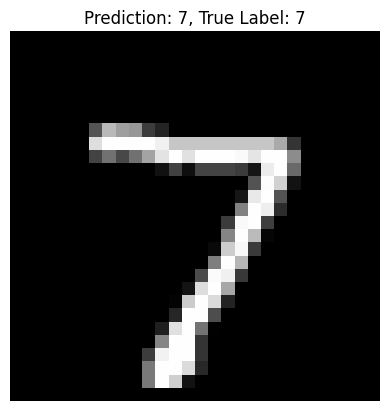

In [25]:
# -------------------- DISPLAY THE IMAGE --------------------
plt.title(f"Prediction: {predicted_label}, True Label: {y_test[index]}")
plt.imshow(x_test[index], cmap='gray')
plt.axis('off')
plt.show()
